In [ ]:
import pandas as pd
orders = pd.read_csv("orders.csv")
order_lines = pd.read_csv("order_lines.csv")


orders['order_placement_date'] = pd.to_datetime(
    orders['order_placement_date'], errors='coerce'
)
order_lines['actual_delivery_date'] = pd.to_datetime(
    order_lines['actual_delivery_date'], errors='coerce'
)


start_date = orders['order_placement_date'].min()
end_date = order_lines['actual_delivery_date'].max()

dim_date = pd.DataFrame({
    'date': pd.date_range(start=start_date, end=end_date, freq='D')
})
dim_date['mmm_yy'] = dim_date['date'].dt.strftime('%b-%y')
dim_date['week_no'] = 'W ' + dim_date['date'].dt.isocalendar().week.astype(str)
dim_date['date'] = dim_date['date'].dt.strftime('%d-%b-%y').str.lstrip('0')
dim_date.head(20)

,date,mmm_yy,week_no
0,1-Mar-22,Mar-22,W 9
1,2-Mar-22,Mar-22,W 9
2,3-Mar-22,Mar-22,W 9
3,4-Mar-22,Mar-22,W 9
4,5-Mar-22,Mar-22,W 9
5,6-Mar-22,Mar-22,W 9
6,7-Mar-22,Mar-22,W 10
7,8-Mar-22,Mar-22,W 10
8,9-Mar-22,Mar-22,W 10
9,10-Mar-22,Mar-22,W 10


In [24]:
dim_date.to_csv("dim_date.csv", index=False)

# code

## Overview

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
customers = pd.read_csv("dim_customers.csv")
products = pd.read_csv("dim_products.csv")
targets = pd.read_csv("dim_targets_orders.csv")
date = pd.read_csv("dim_date.csv")
order_lines = pd.read_csv("fact_order_lines.csv")
orders_agg = pd.read_csv("fact_orders_aggregate.csv")

In [27]:
def overview(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nInfo:")
    print(df.info())
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nHead:")
    display(df.head())

overview(customers, "dim_customers")
overview(products, "dim_products")
overview(targets, "dim_targets_orders")
overview(date, "dim_date")
overview(order_lines, "fact_order_lines")
overview(orders_agg, "fact_orders_aggregate")


===== dim_customers =====
Shape: (37, 5)

Columns:
['customer_id', 'customer_name', 'city', 'load_time', 'run_id']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    37 non-null     int64 
 1   customer_name  37 non-null     object
 2   city           37 non-null     object
 3   load_time      37 non-null     object
 4   run_id         37 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.6+ KB
None

Missing values:
customer_id      0
customer_name    0
city             0
load_time        0
run_id           0
dtype: int64

Duplicate rows: 0

Head:


,customer_id,customer_name,city,load_time,run_id
0,789402,Propel Mart,Ahmedabad,2026-03-19 17:42:04.134253 UTC,manual__2026-03-19T17:40:44.642885+00:00
1,789202,Rel Fresh,Ahmedabad,2026-03-19 17:42:04.134253 UTC,manual__2026-03-19T17:40:44.642885+00:00
2,789902,Elite Mart,Ahmedabad,2026-03-19 17:42:04.134253 UTC,manual__2026-03-19T17:40:44.642885+00:00
3,789102,Vijay Stores,Ahmedabad,2026-03-19 17:42:04.134253 UTC,manual__2026-03-19T17:40:44.642885+00:00
4,789221,Atlas Stores,Ahmedabad,2026-03-19 17:42:04.134253 UTC,manual__2026-03-19T17:40:44.642885+00:00



===== dim_products =====
Shape: (18, 5)

Columns:
['product_id', 'product_name', 'category', 'load_time', 'run_id']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    18 non-null     int64 
 1   product_name  18 non-null     object
 2   category      18 non-null     object
 3   load_time     18 non-null     object
 4   run_id        18 non-null     object
dtypes: int64(1), object(4)
memory usage: 852.0+ bytes
None

Missing values:
product_id      0
product_name    0
category        0
load_time       0
run_id          0
dtype: int64

Duplicate rows: 0

Head:


,product_id,product_name,category,load_time,run_id
0,25891403,AM Curd 50,Dairy,2026-03-19 17:42:04.114682 UTC,manual__2026-03-19T17:40:44.642885+00:00
1,25891201,AM Butter 100,Dairy,2026-03-19 17:42:04.114682 UTC,manual__2026-03-19T17:40:44.642885+00:00
2,25891103,AM Milk 100,Dairy,2026-03-19 17:42:04.114682 UTC,manual__2026-03-19T17:40:44.642885+00:00
3,25891301,AM Ghee 250,Dairy,2026-03-19 17:42:04.114682 UTC,manual__2026-03-19T17:40:44.642885+00:00
4,25891402,AM Curd 100,Dairy,2026-03-19 17:42:04.114682 UTC,manual__2026-03-19T17:40:44.642885+00:00



===== dim_targets_orders =====
Shape: (35, 6)

Columns:
['customer_id', 'ontime_target', 'infull_target', 'otif_target', 'load_time', 'run_id']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    35 non-null     int64  
 1   ontime_target  35 non-null     float64
 2   infull_target  35 non-null     float64
 3   otif_target    35 non-null     float64
 4   load_time      35 non-null     object 
 5   run_id         35 non-null     object 
dtypes: float64(3), int64(1), object(2)
memory usage: 1.8+ KB
None

Missing values:
customer_id      0
ontime_target    0
infull_target    0
otif_target      0
load_time        0
run_id           0
dtype: int64

Duplicate rows: 0

Head:


...

,date,mmm_yy,week_no
0,1-Mar-22,Mar-22,W 9
1,2-Mar-22,Mar-22,W 9
2,3-Mar-22,Mar-22,W 9
3,4-Mar-22,Mar-22,W 9
4,5-Mar-22,Mar-22,W 9



===== fact_order_lines =====
Shape: (57096, 13)

Columns:
['order_line_id', 'order_id', 'customer_id', 'product_id', 'order_placement_date', 'order_qty', 'delivered_qty', 'agreed_delivery_date', 'actual_delivery_date', 'revenue', 'expense', 'load_time', 'run_id']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57096 entries, 0 to 57095
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   order_line_id         57096 non-null  int64 
 1   order_id              57096 non-null  object
 2   customer_id           57096 non-null  int64 
 3   product_id            57096 non-null  int64 
 4   order_placement_date  57096 non-null  object
 5   order_qty             57096 non-null  int64 
 6   delivered_qty         57096 non-null  int64 
 7   agreed_delivery_date  57096 non-null  object
 8   actual_delivery_date  57096 non-null  object
 9   revenue               57096 non-null  int64 
 10  expense       

,order_line_id,order_id,customer_id,product_id,order_placement_date,order_qty,delivered_qty,agreed_delivery_date,actual_delivery_date,revenue,expense,load_time,run_id
0,21611,FMY510103501,789103,25891101,5/8/2022,300,240,5/10/2022,5/10/2022,20880000,17040000,2026-03-19 17:42:24.533543 UTC,manual__2026-03-19T17:40:44.642885+00:00
1,51700,FAUG814422101,789422,25891101,8/12/2022,300,240,8/14/2022,8/17/2022,20880000,17040000,2026-03-19 17:42:24.533543 UTC,manual__2026-03-19T17:40:44.642885+00:00
2,44254,FJUL723601603,789601,25891101,7/20/2022,301,241,7/23/2022,7/23/2022,20967000,17111000,2026-03-19 17:42:24.533543 UTC,manual__2026-03-19T17:40:44.642885+00:00
3,55777,FAUG827202603,789202,25891101,8/25/2022,302,242,8/27/2022,8/27/2022,21054000,17182000,2026-03-19 17:42:24.533543 UTC,manual__2026-03-19T17:40:44.642885+00:00
4,2759,FMR312203103,789203,25891101,3/9/2022,303,242,3/12/2022,3/12/2022,21054000,17182000,2026-03-19 17:42:24.533543 UTC,manual__2026-03-19T17:40:44.642885+00:00



===== fact_orders_aggregate =====
Shape: (31729, 7)

Columns:
['order_id', 'customer_id', 'order_placement_date', 'on_time', 'in_full', 'otif', 'run_id']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31729 entries, 0 to 31728
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   order_id              31729 non-null  object
 1   customer_id           31729 non-null  int64 
 2   order_placement_date  31729 non-null  object
 3   on_time               31729 non-null  int64 
 4   in_full               31729 non-null  int64 
 5   otif                  31729 non-null  int64 
 6   run_id                31729 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.7+ MB
None

Missing values:
order_id                0
customer_id             0
order_placement_date    0
on_time                 0
in_full                 0
otif                    0
run_id                  0
dtype: int64

Duplicate ro

,order_id,customer_id,order_placement_date,on_time,in_full,otif,run_id
0,FMR34101301,789101,3/1/2022,1,1,1,manual__2026-03-19T17:40:44.642885+00:00
1,FMR33101202,789101,3/1/2022,0,1,0,manual__2026-03-19T17:40:44.642885+00:00
2,FMR34101201,789101,3/1/2022,0,1,0,manual__2026-03-19T17:40:44.642885+00:00
3,FMR32101601,789101,3/1/2022,1,1,1,manual__2026-03-19T17:40:44.642885+00:00
4,FMR33101403,789101,3/1/2022,1,0,0,manual__2026-03-19T17:40:44.642885+00:00


### Chuẩn hóa kiểu dữ liệu

In [ ]:
# Chuẩn hóa datetime
date['date'] = pd.to_datetime(date['date'], errors='coerce')
order_lines['order_placement_date'] = pd.to_datetime(order_lines['order_placement_date'], errors='coerce')
order_lines['agreed_delivery_date'] = pd.to_datetime(order_lines['agreed_delivery_date'], errors='coerce')
order_lines['actual_delivery_date'] = pd.to_datetime(order_lines['actual_delivery_date'], errors='coerce')
orders_agg['order_placement_date'] = pd.to_datetime(orders_agg['order_placement_date'], errors='coerce')

# Chuẩn hóa numeric 
numeric_cols_order_lines = ['order_qty', 'delivered_qty', 'revenue', 'expense']
for col in numeric_cols_order_lines:
    order_lines[col] = pd.to_numeric(order_lines[col], errors='coerce')

for col in ['on_time', 'in_full', 'otif']:
    if col in orders_agg.columns:
        orders_agg[col] = pd.to_numeric(orders_agg[col], errors='coerce')

### Kiểm tra khóa chính và tính nhất quán

In [28]:
print("Unique customer_id in dim_customers:", customers['customer_id'].nunique())
print("Duplicate customer_id in dim_customers:", customers['customer_id'].duplicated().sum())

print("Unique product_id in dim_products:", products['product_id'].nunique())
print("Duplicate product_id in dim_products:", products['product_id'].duplicated().sum())

print("Unique date in dim_date:", date['date'].nunique())
print("Duplicate date in dim_date:", date['date'].duplicated().sum())

print("Unique order_line_id in fact_order_lines:", order_lines['order_line_id'].nunique())
print("Duplicate order_line_id in fact_order_lines:", order_lines['order_line_id'].duplicated().sum())

print("Unique order_id in fact_order_aggregate:", orders_agg['order_id'].nunique())
print("Duplicate order_id in fact_order_aggregate:", orders_agg['order_id'].duplicated().sum())

Unique customer_id in dim_customers: 37
Duplicate customer_id in dim_customers: 0
Unique product_id in dim_products: 18
Duplicate product_id in dim_products: 0
Unique date in dim_date: 187
Duplicate date in dim_date: 0
Unique order_line_id in fact_order_lines: 57096
Duplicate order_line_id in fact_order_lines: 0
Unique order_id in fact_order_aggregate: 31729
Duplicate order_id in fact_order_aggregate: 0


In [29]:
## Kiểm tra khóa ngoại có match với dimension k

print("Customer in fact_order_lines not in dim_customers:",
      (~order_lines['customer_id'].isin(customers['customer_id'])).sum())

print("Customer in fact_order_aggregate not in dim_customers:",
      (~orders_agg['customer_id'].isin(customers['customer_id'])).sum())

print("Product in fact_order_lines not in dim_products:",
      (~order_lines['product_id'].isin(products['product_id'])).sum())

Customer in fact_order_lines not in dim_customers: 0
Customer in fact_order_aggregate not in dim_customers: 0
Product in fact_order_lines not in dim_products: 0


## Từng bảng

### dim_customers

Total customers: 37
Total cities: 4
city
Ahmedabad      12
Vadodara       12
Surat          11
Los Angeles     2
Name: count, dtype: int64


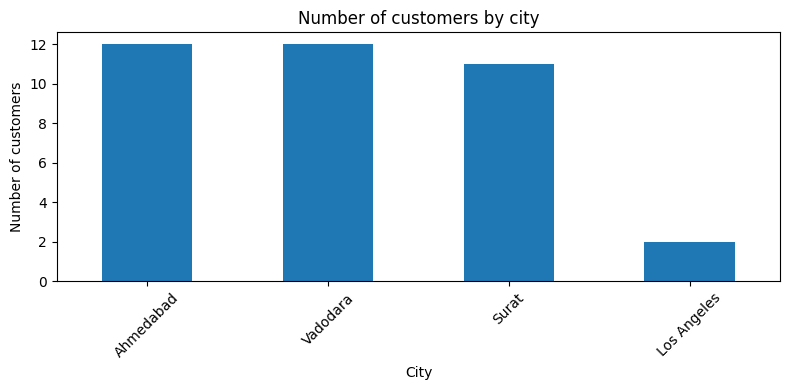

In [64]:
print("Total customers:", customers['customer_id'].nunique())
print("Total cities:", customers['city'].nunique())

top_cities = customers['city'].value_counts().head(10)
print(top_cities)

top_cities.plot(kind='bar', figsize=(8,4))
plt.title("Number of customers by city")
plt.xlabel("City")
plt.ylabel("Number of customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### dim_products

Total products: 18
Total categories: 3


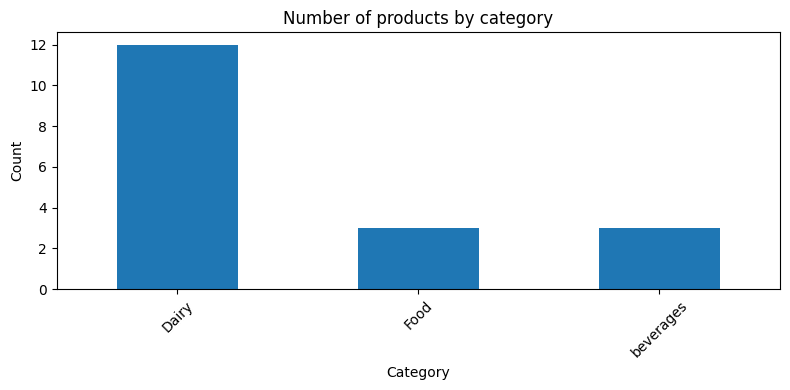

In [31]:
print("Total products:", products['product_id'].nunique())
print("Total categories:", products['category'].nunique())

products['category'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Number of products by category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
valid_products = products.dropna(subset=['product_id', 'product_name', 'category'])
print(len(valid_products))

18


### dim_date

In [69]:
## Xem phạm vi thời gian và có thiếu ngày không.

print("Min date:", date['date'].min())
print("Max date:", date['date'].max())
print("Number of unique dates:", date['date'].nunique())

full_range = pd.date_range(date['date'].min(), date['date'].max(), freq='D')
missing_dates = full_range.difference(date['date'])
print("Missing dates:", len(missing_dates))

Min date: 2022-03-01 00:00:00
Max date: 2022-09-03 00:00:00
Number of unique dates: 187
Missing dates: 0


In [68]:
date['date'] = pd.to_datetime(date['date'], format='%d-%b-%y', errors='coerce')

In [70]:
print("Min date:", date['date'].min())
print("Max date:", date['date'].max())
print("Unique dates:", date['date'].nunique())

Min date: 2022-03-01 00:00:00
Max date: 2022-09-03 00:00:00
Unique dates: 187


In [67]:
order_lines[['order_placement_date', 'actual_delivery_date']].isnull().sum()

order_placement_date    0
actual_delivery_date    0
dtype: int64

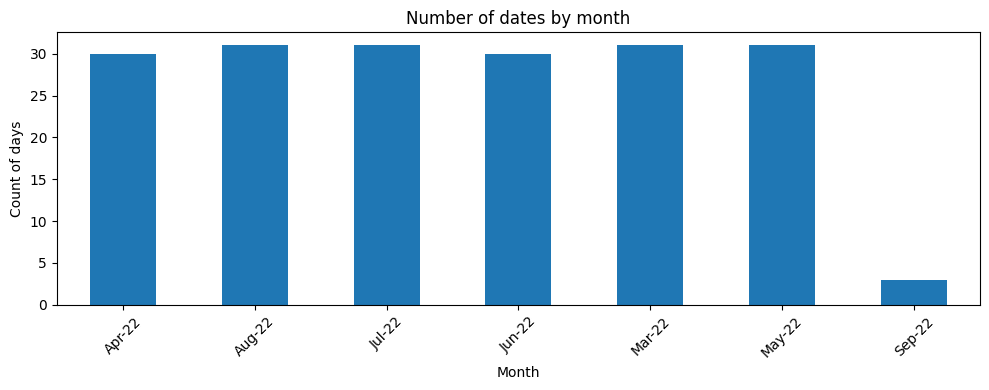

In [ ]:
## Xem số ngày theo tháng

date['mmm_yy'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.title("Number of dates by month")
plt.xlabel("Month")
plt.ylabel("Count of days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### fact_order_lines

In [36]:
print("Total order lines:", len(order_lines))
print("Unique orders:", order_lines['order_id'].nunique())
print("Unique customers:", order_lines['customer_id'].nunique())
print("Unique products:", order_lines['product_id'].nunique())

print("Total ordered quantity:", order_lines['order_qty'].sum())
print("Total delivered quantity:", order_lines['delivered_qty'].sum())
print("Total revenue:", order_lines['revenue'].sum())
print("Total expense:", order_lines['expense'].sum())

order_lines['profit'] = order_lines['revenue'] - order_lines['expense']
print("Total profit:", order_lines['profit'].sum())

Total order lines: 57096
Unique orders: 31729
Unique customers: 35
Unique products: 18
Total ordered quantity: 13426936
Total delivered quantity: 12969157
Total revenue: 1243059528000
Total expense: 983957576000
Total profit: 259101952000


In [38]:
## THống kê mô tả

print(order_lines[['order_qty', 'delivered_qty', 'revenue', 'expense', 'profit']].describe())

          order_qty  delivered_qty       revenue       expense        profit
count  57096.000000   57096.000000  5.709600e+04  5.709600e+04  5.709600e+04
mean     235.164215     227.146508  2.177139e+07  1.723339e+07  4.538005e+06
std      141.001784     137.109465  1.794696e+07  1.424839e+07  3.948685e+06
min       20.000000      16.000000  8.960000e+05  6.400000e+05  2.560000e+05
25%      111.000000     106.000000  7.326000e+06  5.740000e+06  1.440000e+06
50%      207.000000     200.000000  1.476000e+07  1.150500e+07  2.994500e+06
75%      361.000000     347.000000  3.381000e+07  2.754800e+07  6.690000e+06
max      500.000000     500.000000  7.350000e+07  5.900000e+07  1.850000e+07


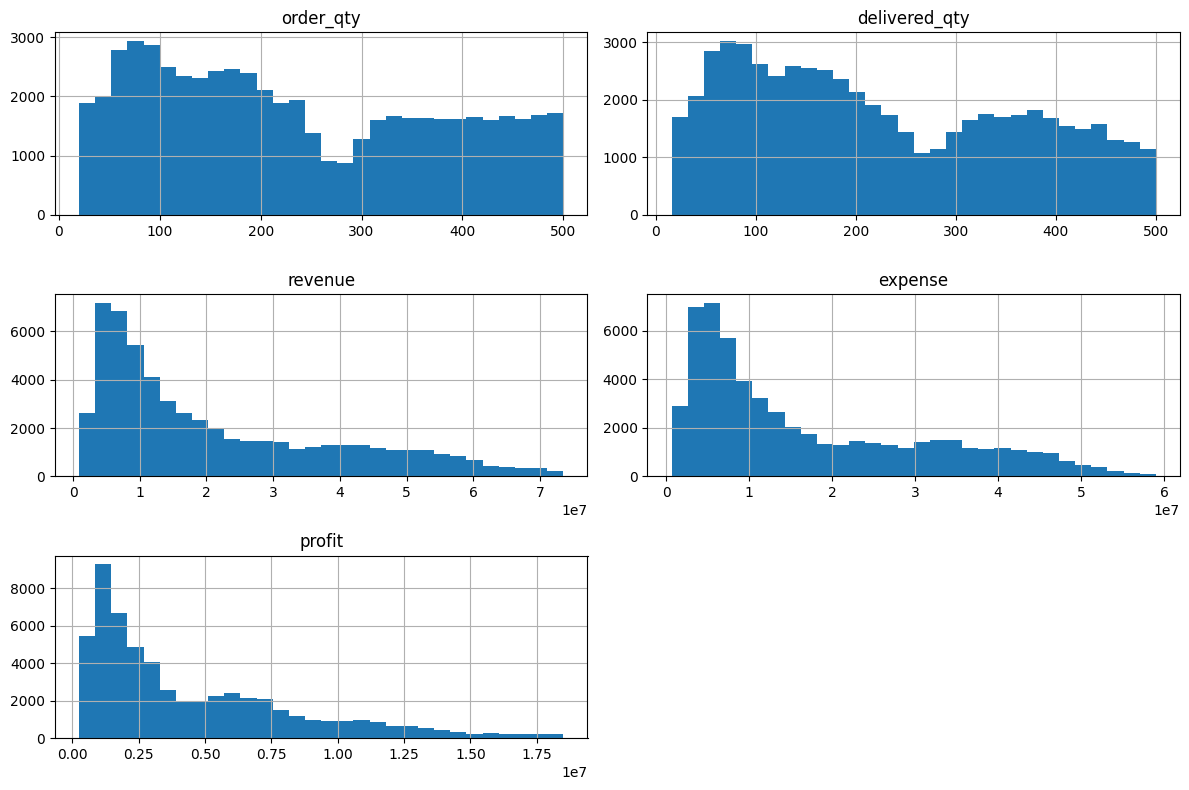

In [40]:
order_lines[['order_qty', 'delivered_qty', 'revenue', 'expense', 'profit']].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

#### Phân tích tình hình giao hàng

In [ ]:
## giao đúng hạn, đủ số lượng  hay k
## 
order_lines['line_on_time'] = (order_lines['actual_delivery_date'] <= order_lines['agreed_delivery_date']).astype(int)
order_lines['line_in_full'] = (order_lines['delivered_qty'] >= order_lines['order_qty']).astype(int)
order_lines['line_otif'] = ((order_lines['line_on_time'] == 1) & (order_lines['line_in_full'] == 1)).astype(int)

print("Line On-time rate:", order_lines['line_on_time'].mean())
print("Line In-full rate:", order_lines['line_in_full'].mean())
print("Line OTIF rate:", order_lines['line_otif'].mean())

Line On-time rate: 0.725147120638924
Line In-full rate: 0.6596083788706739
Line OTIF rate: 0.4874597169679137


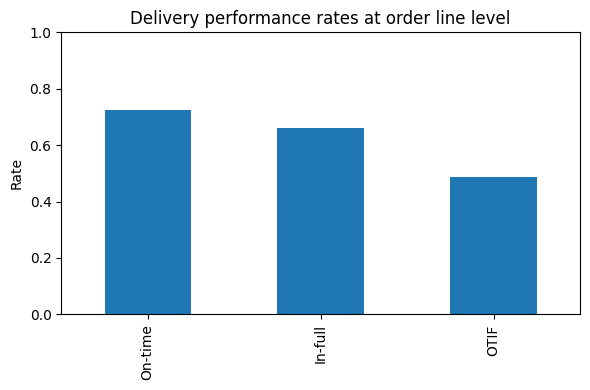

In [43]:
rates = pd.Series({
    'On-time': order_lines['line_on_time'].mean(),
    'In-full': order_lines['line_in_full'].mean(),
    'OTIF': order_lines['line_otif'].mean()
})

rates.plot(kind='bar', figsize=(6,4))
plt.title("Delivery performance rates at order line level")
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### fact_order_aggregate

In [44]:
print("Total orders:", orders_agg['order_id'].nunique())
print("On-time rate:", orders_agg['on_time'].mean())
print("In-full rate:", orders_agg['in_full'].mean())
print("OTIF rate:", orders_agg['otif'].mean())

Total orders: 31729
On-time rate: 0.5903117022282455
In-full rate: 0.5278136720350468
OTIF rate: 0.29020769642913424


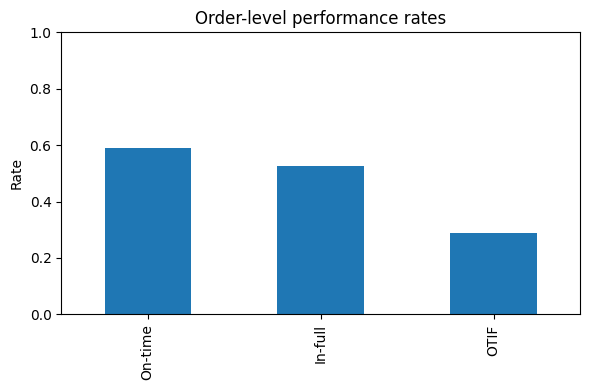

In [45]:
order_rates = pd.Series({
    'On-time': orders_agg['on_time'].mean(),
    'In-full': orders_agg['in_full'].mean(),
    'OTIF': orders_agg['otif'].mean()
})

order_rates.plot(kind='bar', figsize=(6,4))
plt.title("Order-level performance rates")
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#### Phân tích theo thời gian

order_placement_date
3/1/2022     186
3/10/2022    171
3/11/2022    187
3/12/2022    181
3/13/2022    169
            ... 
8/5/2022     167
8/6/2022     177
8/7/2022     179
8/8/2022     183
8/9/2022     185
Name: order_id, Length: 183, dtype: int64


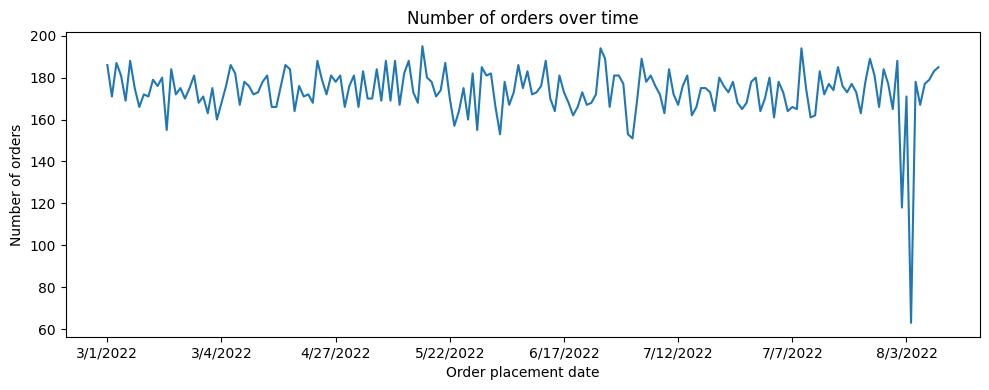

In [65]:
## số đơn theo ngày

orders_by_day = orders_agg.groupby('order_placement_date')['order_id'].count()
print(orders_by_day)
orders_by_day.plot(figsize=(10,4))
plt.title("Number of orders over time")
plt.xlabel("Order placement date")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()

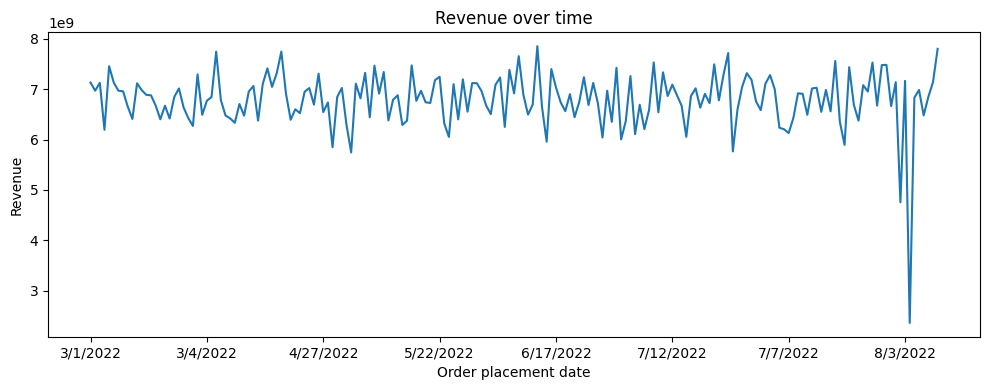

In [ ]:
## revenue theo ngày

revenue_by_day = order_lines.groupby('order_placement_date')['revenue'].sum()

revenue_by_day.plot(figsize=(10,4))
plt.title("Revenue over time")
plt.xlabel("Order placement date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

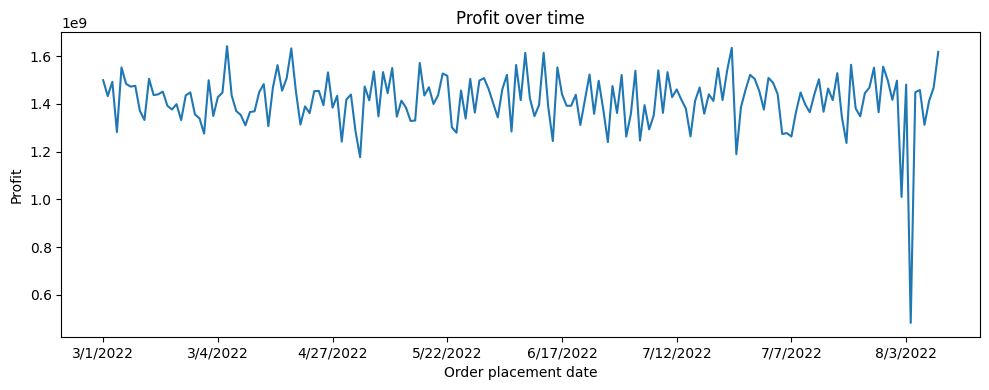

In [48]:
## profit theo ngày

profit_by_day = order_lines.groupby('order_placement_date')['profit'].sum()

profit_by_day.plot(figsize=(10,4))
plt.title("Profit over time")
plt.xlabel("Order placement date")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

## Gộp bảng

### Phân tích theo khách hàng

customer_name
Rel Fresh            108211755000
Vijay Stores         108192323000
Propel Mart          106609873000
Lotus Mart           106321907000
Acclaimed Stores     102697714000
Expert Mart           73784007000
Expression Stores     72126740000
Viveks Stores         71279627000
Coolblue              70934262000
Atlas Stores          70890487000
Name: revenue, dtype: int64


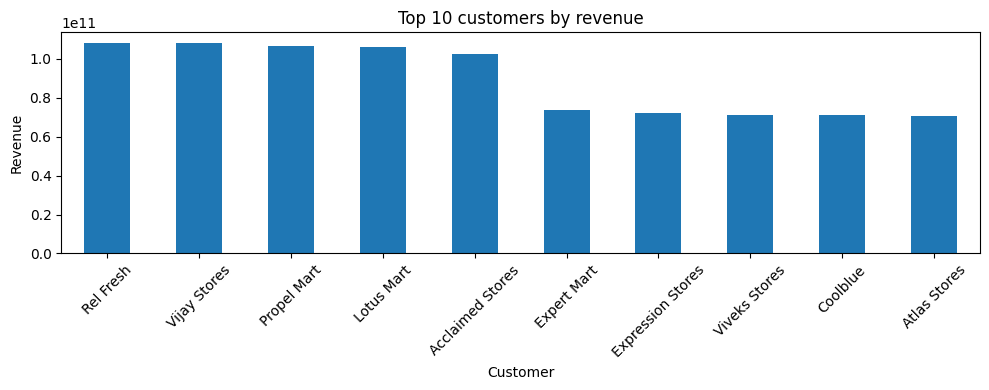

In [ ]:
## Doanh thu theo theo khách hằng

customer_perf = order_lines.merge(customers, on='customer_id', how='left')

top_customers = customer_perf.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

top_customers.plot(kind='bar', figsize=(10,4))
plt.title("Top 10 customers by revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

city
Ahmedabad    427200114000
Vadodara     427004892000
Surat        388854522000
Name: revenue, dtype: int64


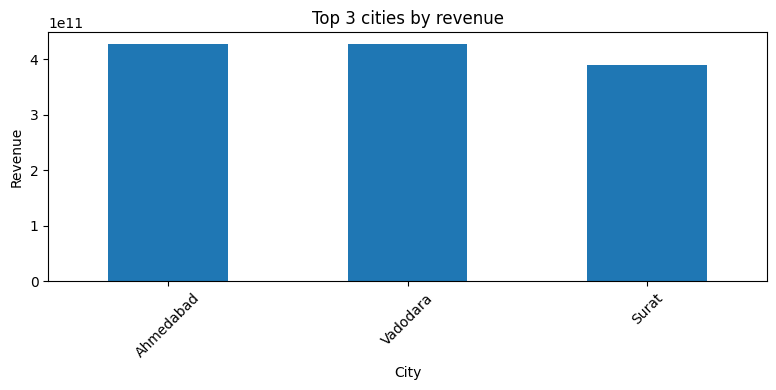

In [66]:
## Doanh thu theo thành phố

revenue_by_city = customer_perf.groupby('city')['revenue'].sum().sort_values(ascending=False).head(10)
print(revenue_by_city)

revenue_by_city.plot(kind='bar', figsize=(8,4))
plt.title("Top 3 cities by revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
## Hiệu suất giao hành theo khách hàng

customer_order_perf = orders_agg.merge(customers, on='customer_id', how='left')

cust_otif = customer_order_perf.groupby('customer_name')[['on_time', 'in_full', 'otif']].mean().sort_values(by='otif', ascending=False).head(10)
print(cust_otif)

                    on_time   in_full      otif
customer_name                                  
Propel Mart        0.736386  0.597360  0.409241
Atlas Stores       0.718104  0.597813  0.395504
Viveks Stores      0.706062  0.600735  0.394366
Expert Mart        0.725407  0.598069  0.391068
Logic Stores       0.708234  0.601432  0.387828
Chiptec Stores     0.716200  0.603532  0.387333
Expression Stores  0.699158  0.608303  0.383875
Rel Fresh          0.723240  0.586895  0.381766
Vijay Stores       0.724473  0.449757  0.282820
Sorefoz Mart       0.726671  0.391933  0.258880


### Phân tích theo sản phẩm

In [54]:
product_perf = order_lines.merge(products, on='product_id', how='left')

product_name
AM Milk 250        179187955000
AM Curd 50         158968887000
AM Milk 100        151533417000
AM Curd 250        128663777000
AM Milk 500        105539178000
AM Butter 100      100243000000
AM Butter 500       62594070000
AM Butter 250       59343966000
AM Curd 100         55535324000
AM Biscuits 750     46933542000
Name: revenue, dtype: int64


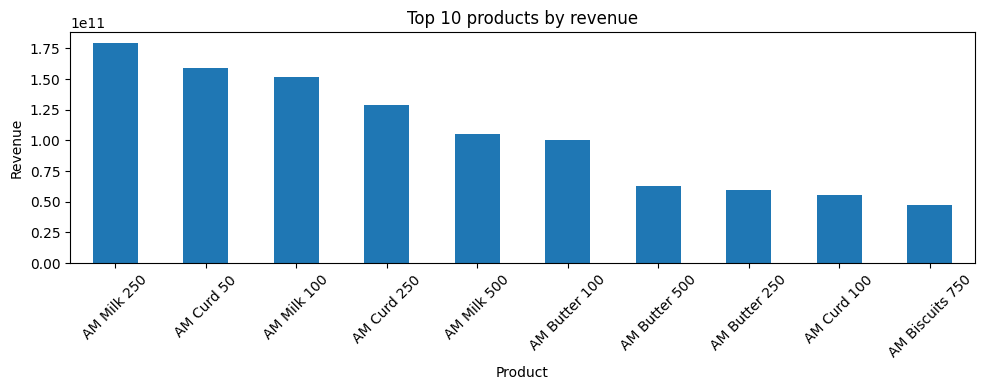

In [55]:
## Top sản phẩm theo doanh thu

top_products = product_perf.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_products)

top_products.plot(kind='bar', figsize=(10,4))
plt.title("Top 10 products by revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

category
Dairy        1057377775000
beverages      99779161000
Food           85902592000
Name: revenue, dtype: int64


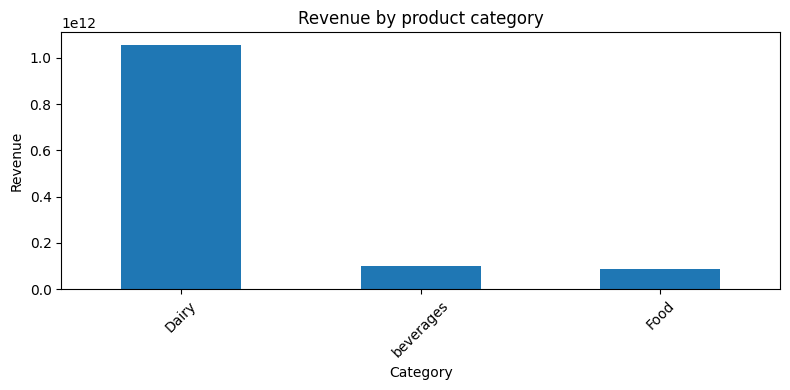

In [56]:
## revenue theo category

revenue_by_category = product_perf.groupby('category')['revenue'].sum().sort_values(ascending=False)
print(revenue_by_category)

revenue_by_category.plot(kind='bar', figsize=(8,4))
plt.title("Revenue by product category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

category
Dairy        214715421000
beverages     30872147000
Food          13514384000
Name: profit, dtype: int64


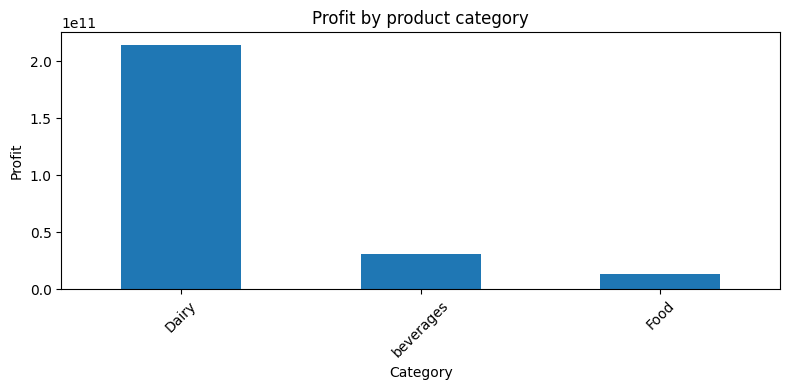

In [57]:
## profit theo category

profit_by_category = product_perf.groupby('category')['profit'].sum().sort_values(ascending=False)
print(profit_by_category)

profit_by_category.plot(kind='bar', figsize=(8,4))
plt.title("Profit by product category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### actual & target

In [58]:
actual_vs_target = (
    orders_agg.groupby('customer_id')[['on_time', 'in_full', 'otif']]
    .mean()
    .reset_index()
    .merge(targets, on='customer_id', how='left')
    .merge(customers, on='customer_id', how='left')
)

actual_vs_target['ontime_gap'] = actual_vs_target['on_time'] - actual_vs_target['ontime_target']
actual_vs_target['infull_gap'] = actual_vs_target['in_full'] - actual_vs_target['infull_target']
actual_vs_target['otif_gap'] = actual_vs_target['otif'] - actual_vs_target['otif_target']

print(actual_vs_target.head())

   customer_id   on_time   in_full      otif  ontime_target  infull_target  \
0       789101  0.725944  0.583435  0.381242           0.86           0.80   
1       789102  0.698317  0.582933  0.359375           0.90           0.81   
2       789103  0.749693  0.179141  0.105521           0.92           0.67   
3       789121  0.296144  0.671862  0.203445           0.78           0.77   
4       789122  0.286535  0.222496  0.071429           0.76           0.65   

   otif_target                     load_time_x  \
0         0.69  2026-03-19 17:42:13.476480 UTC   
1         0.73  2026-03-19 17:42:13.476480 UTC   
2         0.62  2026-03-19 17:42:13.476480 UTC   
3         0.60  2026-03-19 17:42:13.476480 UTC   
4         0.49  2026-03-19 17:42:13.476480 UTC   

                                   run_id_x customer_name       city  \
0  manual__2026-03-19T17:40:44.642885+00:00  Vijay Stores      Surat   
1  manual__2026-03-19T17:40:44.642885+00:00  Vijay Stores  Ahmedabad   
2  manual__202

In [59]:
## xem khách nào chưa đạt target

under_otif = actual_vs_target.sort_values('otif_gap').head(10)
print(under_otif[['customer_name', 'otif', 'otif_target', 'otif_gap']])

       customer_name      otif  otif_target  otif_gap
25       Info Stores  0.094317         0.62 -0.525683
2       Vijay Stores  0.105521         0.62 -0.514479
34        Elite Mart  0.097171         0.60 -0.502829
29      Sorefoz Mart  0.106971         0.59 -0.483029
19        Lotus Mart  0.196918         0.64 -0.443082
22  Acclaimed Stores  0.069272         0.51 -0.440728
18        Lotus Mart  0.079729         0.51 -0.430271
23  Acclaimed Stores  0.190955         0.62 -0.429045
4           Coolblue  0.071429         0.49 -0.418571
24  Acclaimed Stores  0.199160         0.60 -0.400840


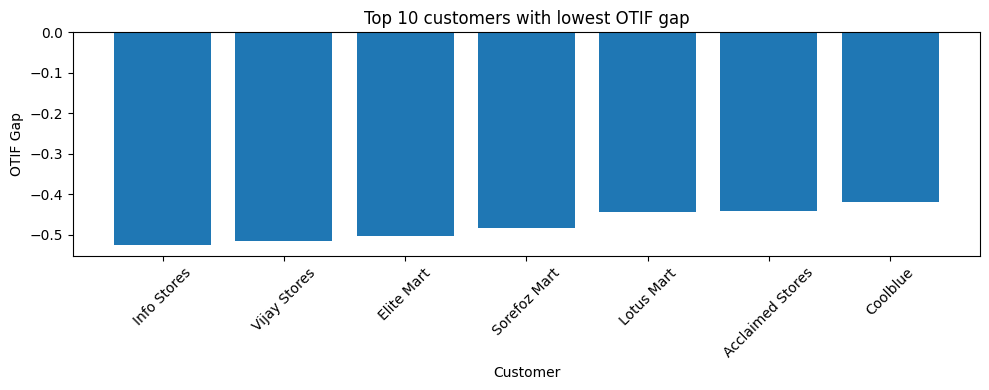

In [60]:
otif_gap_plot = actual_vs_target.sort_values('otif_gap').head(10)

plt.figure(figsize=(10,4))
plt.bar(otif_gap_plot['customer_name'], otif_gap_plot['otif_gap'])
plt.title("Top 10 customers with lowest OTIF gap")
plt.xlabel("Customer")
plt.ylabel("OTIF Gap")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import os


folder = 'clean_data'
os.makedirs(folder, exist_ok=True)


customers.to_csv(f'{folder}/dim_customers.csv', index=False)
products.to_csv(f'{folder}/dim_products.csv', index=False)
date.to_csv(f'{folder}/dim_date.csv', index=False)
targets.to_csv(f'{folder}/dim_targets_orders.csv', index=False)
order_lines.to_csv(f'{folder}/fact_order_lines.csv', index=False)
orders_agg.to_csv(f'{folder}/fact_orders_aggregate.csv', index=False)

print("Đã xuất xong tất cả file vào folder 'clean_data/'")

Đã xuất xong tất cả file vào folder 'clean_data/'
